In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# Load Data

In [62]:
DATA_ROOT_PATH      = "/home/frankie/WCIS/FLASH-ADC-CHARACTERIZATION/ramp_data_final/1khz_in"
POWER_MODES       = ["HPM", "RPM", "LPM"]
FS_STR_LIST       = ["500k", "1M", "2M", "3M", "4M", "5M", "6M"]
FS_LIST           = [500e3, 1e6, 2e6, 3e6, 4e6, 5e6, 6e6]
FI_LIST           = [99.915e3, 99.976e3, 99.854e3, 99.976e3, 100.098e3, 99.487e3, 98.877e3]
J_LIST            = [1637, 819, 409, 273, 205, 163, 135]
BUFFER_SIZE       = 8192
REF_HI            = 2.8
REF_LO            = 0.8
SHUNT_RESISTANCE  = 1.02

SHUNT_VOLTAGE = {
    "HPM": {"500k": 4.62e-3, "1M": 4.98e-3, "2M": 5.62e-3, "3M": 6.16e-3, "4M": 6.74e-3, "5M": 7.32e-3, "6M": 0},
    "RPM": {"500k": 3.25e-3, "1M": 3.60e-3, "2M": 4.20e-3, "3M": 4.80e-3, "4M": 5.38e-3, "5M": 5.93e-3, "6M": 0},
    "LPM": {"500k": 2.50e-3, "1M": 2.89e-3, "2M": 3.52e-3, "3M": 3.96e-3, "4M": 4.39e-3, "5M": 4.98e-3, "6M": 0},
}

POWER_W = {
    pm: {fs: (v**2 / SHUNT_RESISTANCE) for fs, v in fs_dict.items()}
    for pm, fs_dict in SHUNT_VOLTAGE.items()
}

hann_window = np.hanning(BUFFER_SIZE)

In [63]:
raw_dfs = {pm: pd.DataFrame() for pm in POWER_MODES}

for power_mode_folder in os.listdir(DATA_ROOT_PATH):
    power_mode_folder_path = os.path.join(DATA_ROOT_PATH, power_mode_folder)
    if os.path.isdir(power_mode_folder_path) and power_mode_folder in POWER_MODES:
        for Fs_folder in os.listdir(power_mode_folder_path):
            Fs_path = os.path.join(power_mode_folder_path, Fs_folder)
            if os.path.isdir(Fs_path):
                for csv_file in glob.glob(os.path.join(Fs_path, "*.csv")):
                    df = pd.read_csv(csv_file)
                    for k, col in enumerate(df.columns):
                        raw_dfs[power_mode_folder][Fs_folder + str(k)] = df[col]


/tmp/ipykernel_105128/785189184.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw_dfs[power_mode_folder][Fs_folder + str(k)] = df[col]


In [64]:
# Pick power mode and Fs to analyze
pm_plot     = "HPM"
fs_plot     = "4M"

# Gather all codes across all captures for this pm/fs
test_cols = [c for c in raw_dfs[pm_plot].columns if c.startswith(fs_plot)]
all_codes = np.concatenate([raw_dfs[pm_plot][col].dropna().values.astype(int)
                             for col in test_cols])

print(f"Total samples : {len(all_codes)}")
print(f"Unique codes  : {len(np.unique(all_codes))}")
print(f"Code range    : {all_codes.min()} – {all_codes.max()}")


Total samples : 3276800
Unique codes  : 207
Code range    : 0 – 255


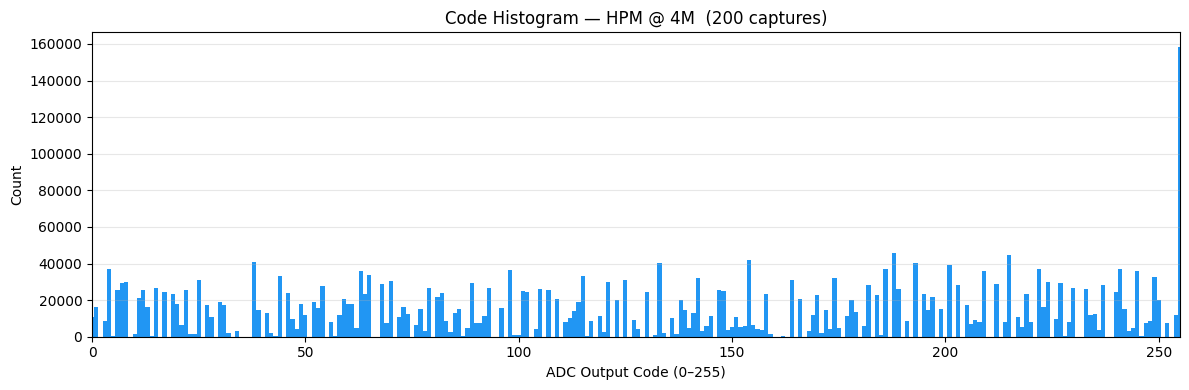

In [65]:

# Plot Histogram
fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(np.arange(256),
       np.bincount(all_codes, minlength=256),
       width=1.0, color="#2196F3", edgecolor="none")

ax.set_title(f"Code Histogram — {pm_plot} @ {fs_plot}  ({len(test_cols)} captures)")
ax.set_xlabel("ADC Output Code (0–255)")
ax.set_ylabel("Count")
ax.set_xlim(0, 255)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Find CTL Function T[k]

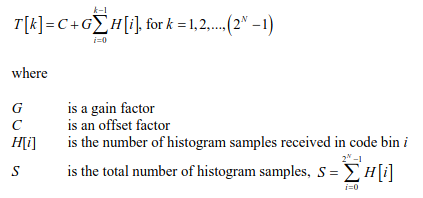


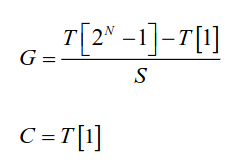

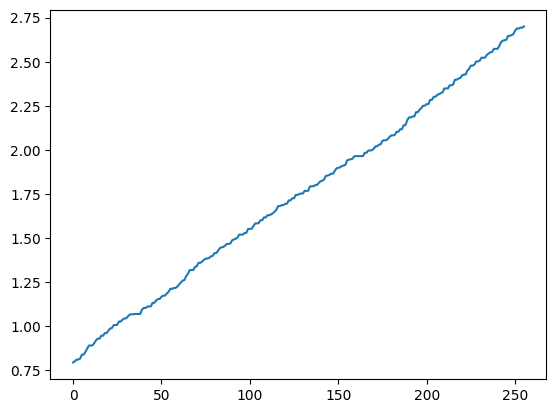

In [66]:
T1 = 0.8        # ref low of ADC FSR
T_last = 2.7    # ref high of ADC FSR
S = len(all_codes)

H = np.bincount(all_codes, minlength=256).astype(float)

G = (T_last - T1) / (S - H[255] - H[0])
C = T1 - H[0] * (T_last - T1) / (S - H[255] - H[0])



T = np.zeros(256)

for k in range(0, 256):
    T[k] = C + G * np.sum(H[:k])

plt.plot(T)

# GAIN & OFFSET
#### Independently Based

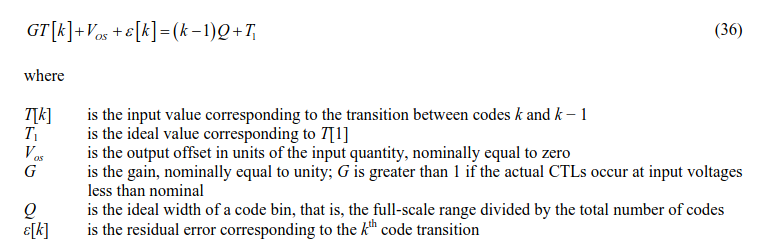

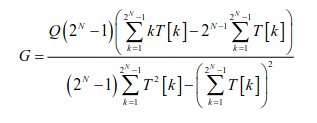



In [67]:
FSR = T_last - T1
Q = FSR / 256
M = 255  # 2^N - 1

k = np.arange(1, M + 1)
T_vals = T[1:M + 1]

sum_kT  = np.sum(k * T_vals)
sum_T   = np.sum(T_vals)
sum_T2  = np.sum(T_vals ** 2)



GAIN = (Q * M * (sum_kT - 2**(8 - 1) * sum_T)) / (M * sum_T2 - sum_T**2)


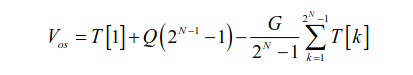

In [68]:


k = np.arange(1, M + 1)
T_vals = T[1:M + 1]

sum_T = np.sum(T_vals)

OFFSET = T[1] + Q * (2**(8-1) - 1) - ((GAIN) / (M)) * sum_T


In [69]:
print(f"GAIN: {GAIN}")
print(f"OFFSET: {OFFSET}")

GAIN: 1.0178149146170252
OFFSET: -0.033428018782326596


## Terminal Based

In [70]:
GAIN = ((2**8 - 2) * Q) / (T[2**8 - 1] - T1)

OFFSET = T1 - GAIN * T1

In [71]:
print(f"GAIN: {GAIN}")
print(f"OFFSET: {OFFSET}")

GAIN: 0.9921875
OFFSET: 0.006249999999999978


In [72]:
k_vals = np.arange(1, 256)
T_nom  = REF_LO + (k_vals - 1) * Q   # ideal CTL for k=1..255, shape (255,)

In [73]:
T_corrected = (T * GAIN) + OFFSET

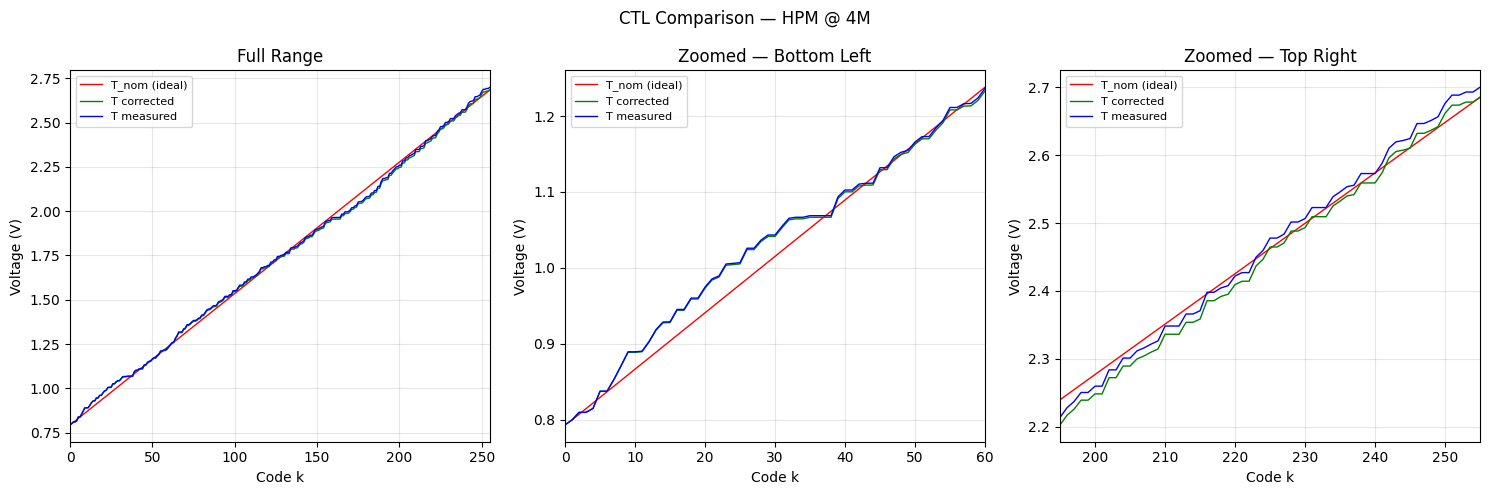

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

T_nom_full = np.full(256, np.nan)
T_nom_full[1:256] = T_nom   # T_nom lives at indices 1..255



plot_data = [
    (T_nom_full,    "T_nom (ideal)", "red"),
    (T_corrected,  "T corrected",   "green"),
    (T,             "T measured",    "blue"),
]

xlims = [
    (0,   255),   # full view
    (0,   60),    # bottom left
    (195, 255),   # top right
]
titles = ["Full Range", "Zoomed — Bottom Left", "Zoomed — Top Right"]

for ax, (xl, title) in zip(axes, zip(xlims, titles)):
    for data, label, color in plot_data:
        ax.plot(data, label=label, color=color, linewidth=1.0)
    ax.set_xlim(xl)
    # set ylim to match the data range in that x window
    idx = np.arange(int(xl[0]), int(xl[1]) + 1)
    all_vals = np.concatenate([d[idx] for d, _, _ in plot_data if not np.all(np.isnan(d[idx]))])
    ymin, ymax = np.nanmin(all_vals), np.nanmax(all_vals)
    margin = (ymax - ymin) * 0.05
    ax.set_ylim(ymin - margin, ymax + margin)
    ax.set_title(title)
    ax.set_xlabel("Code k")
    ax.set_ylabel("Voltage (V)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"CTL Comparison — {pm_plot} @ {fs_plot}")
plt.tight_layout()
plt.show()

# INL

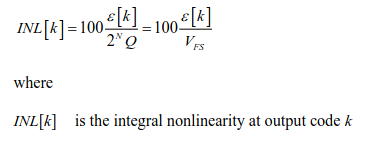

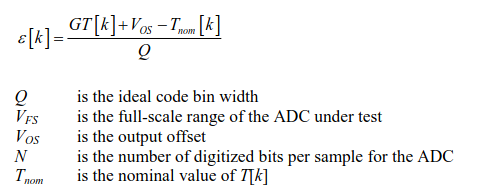

In [75]:
active_mask = H[1:256] > 0          # active codes only
k_active    = k_vals[active_mask]
T_active    = T[1:256][active_mask]
T_nom_active = T_nom[active_mask]

residual_error = ((GAIN * T_active + OFFSET) - T_nom_active) / Q   # INL in LSBs, active codes only

In [76]:
INL = (residual_error / FSR)

# DNL

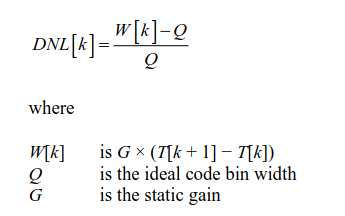

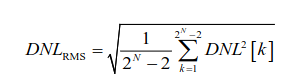

In [77]:
W = GAIN * (T[2:256] - T[1:255])


DNL = np.full(256, np.nan)
DNL[1:255] = (W - Q) / Q

DNL[1:255][H[1:255] == 0] = -1.0    # missing codes = -1.0

In [78]:
k_range = np.arange(1, 255)
sum_dnl2 = np.nansum(DNL[k_range]**2)

DNL_rms = np.sqrt( (1 / (256 - 2)) * sum_dnl2)


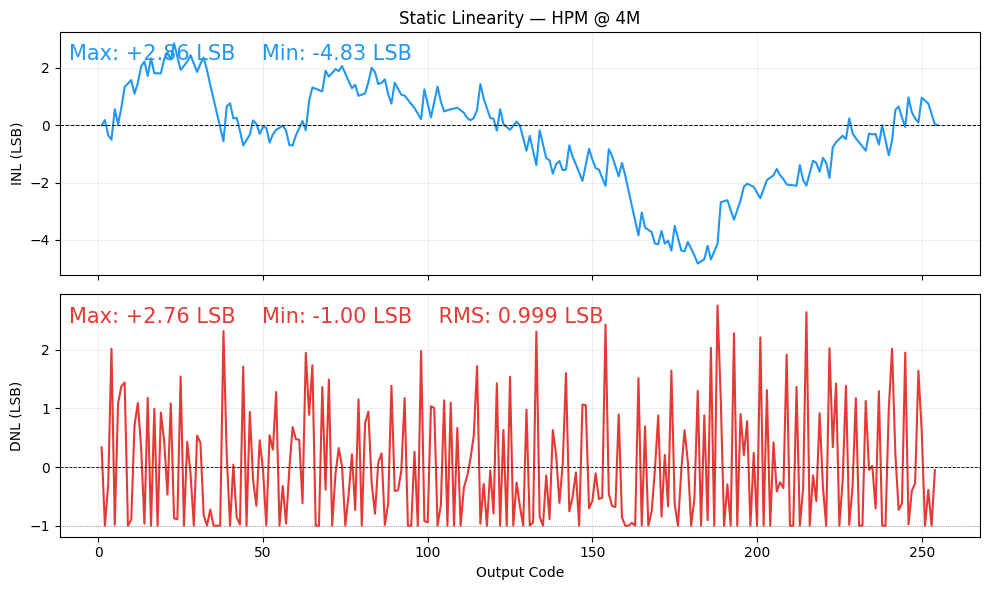

In [79]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

k_all = np.arange(256)

# ── INL ───────────────────────────────────────────────────────────────────────
ax1.plot(k_active, INL, color="#2196F3", linewidth=1.5)
ax1.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax1.set_ylabel("INL (LSB)")
ax1.set_title(f"Static Linearity — {pm_plot} @ {fs_plot}")
ax1.annotate(f"Max: {np.nanmax(INL):+.2f} LSB    Min: {np.nanmin(INL):+.2f} LSB",
             xy=(0.01, 0.95), xycoords="axes fraction",
             fontsize=15, va="top", color="#2196F3")
ax1.grid(True, alpha=0.2)

# ── DNL ───────────────────────────────────────────────────────────────────────
ax2.plot(k_all, DNL, color="#E53935", linewidth=1.5)
ax2.axhline( 0,  color="black",  linewidth=0.6, linestyle="--")
ax2.axhline(-1,  color="gray",   linewidth=0.6, linestyle=":")
ax2.set_ylabel("DNL (LSB)")
ax2.set_xlabel("Output Code")
ax2.annotate(f"Max: {np.nanmax(DNL):+.2f} LSB    Min: {np.nanmin(DNL):+.2f} LSB    RMS: {DNL_rms:.3f} LSB",
             xy=(0.01, 0.95), xycoords="axes fraction",
             fontsize=15, va="top", color="#E53935")
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [80]:
print("HI")

HI
